In [1]:
import os
import kagglehub

if not os.path.exists("/root/.cache/kagglehub"):
    path = kagglehub.dataset_download("ulrikthygepedersen/video-games-sales")

else:
    print("sudah ada, skip")


path = "/root/.cache/kagglehub/datasets/ulrikthygepedersen/video-games-sales/versions/1"
print("Path to dataset files:", path)

os.listdir(path)

sudah ada, skip
Path to dataset files: /root/.cache/kagglehub/datasets/ulrikthygepedersen/video-games-sales/versions/1


['video_games_sales.csv']

## 1. Persiapan Data

Dataset yang digunakan adalah Video Game Sales dari Kaggle.  
Dataset ini berisi informasi penjualan game berdasarkan berbagai faktor.

- Jumlah data: 16.000+ baris
- Fitur:
  - Name (nama game)
  - Platform
  - Year
  - Genre
  - Publisher
  - NA_Sales, EU_Sales, dll
- Target: Global_Sales

Dataset ini digunakan untuk memprediksi penjualan global berdasarkan Trend Penjualan per Tahun.

## 2. Eksplorasi Data (EDA)

Berikut adalah beberapa isi baris data

In [2]:
import pandas as pd

file_path = path + "/video_games_sales.csv"
df = pd.read_csv(file_path)

df.head()

,rank,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


Berikut adalah visualisasi hubungan antara variabel independen dan dependen

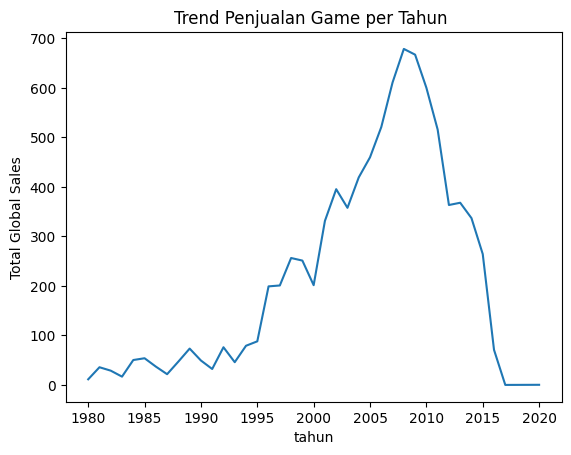

In [3]:
import matplotlib.pyplot as plt

x = df[['year']].values

y = df['global_sales'].values
penjualan_tahunan = df.groupby('year')['global_sales'].sum()
plt.plot(penjualan_tahunan.index, penjualan_tahunan.values)
plt.xlabel('tahun')
plt.ylabel('Total Global Sales')
plt.title('Trend Penjualan Game per Tahun ')
plt.show()

## 3. Pembangunan Model

Setelah melakukan Eksplorasi Data (EDA) dan melihat adanya tren perubahan total penjualan game global dari tahun ke tahun, langkah selanjutnya adalah membangun model prediktif. Pada tahap ini, kita akan menggunakan algoritma Linear Regression untuk mengajarkan komputer mengenali pola hubungan antara Tahun Rilis (variabel independen) dan Penjualan Global (variabel dependen). Data akan dibagi menjadi dua bagian: Training Set untuk melatih model, dan Testing Set untuk menguji seberapa baik model kita bisa melakukan prediksi.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df_clean = df.dropna(subset=['year', 'global_sales'])

X = df_clean[['year']].values
y = df_clean['global_sales'].values

# Pisahkan data menjadi training set (80%) dan testing set (20%)
# random_state=42 digunakan agar hasil acakan pembagian datanya selalu sama setiap kali di-run
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()

# Latih model dengan data training (mengajarkan mesin mencari garis regresi terbaik)
model.fit(X_train, y_train)

print("Model Linear Regression berhasil dilatih dengan data training!")
print(f"Jumlah data training : {len(X_train)} baris")
print(f"Jumlah data testing  : {len(X_test)} baris")

Model Linear Regression berhasil dilatih dengan data training!
Jumlah data training : 13061 baris
Jumlah data testing  : 3266 baris


## 4. Evaluasi Model

Pada tahap ini, model yang telah dilatih menggunakan data training (80% data) diuji kemampuannya. Model diberikan data testing (berupa kumpulan Tahun Rilis) yang belum pernah ia lihat sebelumnya, lalu diminta untuk memprediksi (menebak) berapa jumlah Global Sales-nya. Hasil tebakan ini kemudian akan dibandingkan dengan data Global Sales yang asli untuk dinilai akurasinya

In [5]:
from sklearn.metrics import mean_squared_error, r2_score

#prediksi pada data testing
# Model disuruh menebak Total Penjualan (Y) hanya dengan melihat Tahun (X_test)
y_pred = model.predict(X_test)


# Tampilkan nilai koefisien regresi (slope & intercept)

print("=== NILAI PERSAMAAN GARIS REGRESI ===")
print(f"Slope (Kemiringan) : {model.coef_[0]:.4f}")
print(f"Intercept (Awal Y) : {model.intercept_:.4f}")
print(f"Rumus Matematika   : Y = {model.coef_[0]:.4f}*X + ({model.intercept_:.4f})")

# Hitung dan tampilkan R2 Score dan Mean Squared Error (MSE)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== HASIL EVALUASI MODEL (RAPOR) ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"R-squared (R2) Score     : {r2:.4f}")

=== NILAI PERSAMAAN GARIS REGRESI ===
Slope (Kemiringan) : -0.0220
Intercept (Awal Y) : 44.7537
Rumus Matematika   : Y = -0.0220*X + (44.7537)

=== HASIL EVALUASI MODEL (RAPOR) ===
Mean Squared Error (MSE) : 4.2719
R-squared (R2) Score     : 0.0001


## 5. Visualisasi Hasil

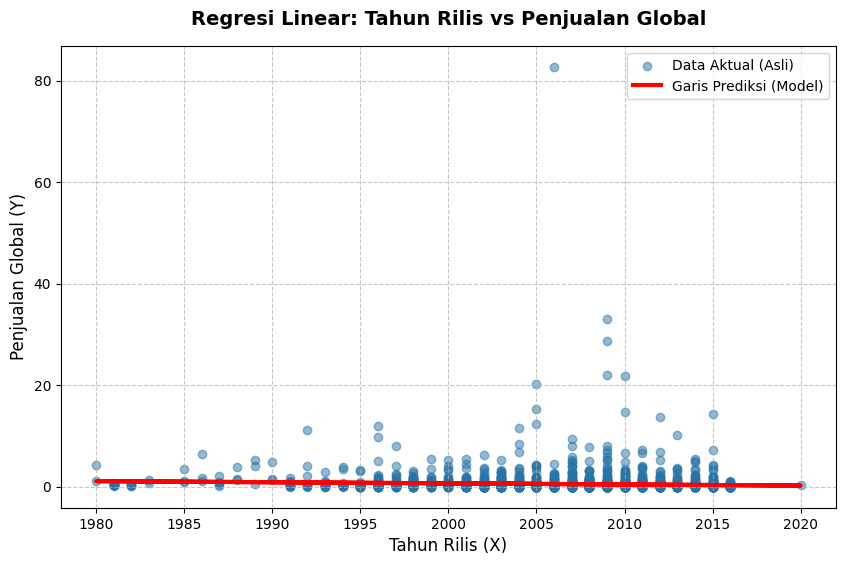


=== PERBANDINGAN NILAI AKTUAL VS PREDIKSI (10 Data Pertama) ===
   Tahun Rilis (X)  Penjualan Aktual (Y Asli)  Tebakan Model (Y Prediksi)
0           2005.0                       0.33                    0.563369
1           2002.0                       0.15                    0.629489
2           2005.0                       0.42                    0.563369
3           2010.0                       0.89                    0.453169
4           2016.0                       0.09                    0.320928
5           2006.0                       0.11                    0.541329
6           2011.0                       0.03                    0.431128
7           2005.0                       0.06                    0.563369
8           2015.0                       0.01                    0.342968
9           2007.0                       0.09                    0.519289


In [6]:
# Tampilkan plot garis regresi dan titik data aktual
plt.figure(figsize=(10, 6))

# Menggambar titik-titik data aktual dari Data Testing (warna biru)
plt.scatter(X_test, y_test, color='#2874A6', alpha=0.5, label='Data Aktual (Asli)')

# Menggambar garis regresi hasil prediksi model (warna merah)
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Garis Prediksi (Model)')

plt.title('Regresi Linear: Tahun Rilis vs Penjualan Global', fontsize=14, weight='bold', pad=15)
plt.xlabel('Tahun Rilis (X)', fontsize=12)
plt.ylabel('Penjualan Global (Y)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Bandingkan hasil prediksi dengan nilai aktual
print("\n=== PERBANDINGAN NILAI AKTUAL VS PREDIKSI (10 Data Pertama) ===")
# X_test.flatten() digunakan untuk mengubah matriks 2D kembali menjadi daftar angka biasa
tabel_perbandingan = pd.DataFrame({
    'Tahun Rilis (X)': X_test.flatten(),
    'Penjualan Aktual (Y Asli)': y_test,
    'Tebakan Model (Y Prediksi)': y_pred
})

# Menampilkan 10 baris pertama
print(tabel_perbandingan.head(10))

##6. Analisis dan Kesimpulan
1.Penjelasan interpretasi hasil model:
- Slope (Kemiringan = -0.0220): Nilai negatif ini menunjukkan bahwa model regresi menarik garis tren yang sedikit menurun. Secara matematis, model memprediksi adanya penurunan penjualan global sebesar 0,022 juta kopi setiap bertambahnya satu tahun rilis.

- Intercept (Titik Awal = 44.7537): Ini adalah nilai titik potong pada sumbu Y. Artinya, persamaan matematika model memprediksi penjualan sebesar 44,75 juta kopi pada "Tahun 0". Nilai ini murni untuk melengkapi persamaan garis lurus dan tidak memiliki konteks historis di dunia nyata.

2.Seberapa Baik Model Memprediksi Data?
- Model ini sangat buruk dalam memprediksi data. Hal ini dibuktikan dari skor evaluasi:
  - R-squared (R2) Score sebesar 0.0001 (hanya 0,01%). Artinya, variabel Year hampir tidak bisa menjelaskan variasi dari Global Sales.
  - Hasil visualisasi (plot) menunjukkan bahwa penjualan game memiliki tren fluktuatif yang membentuk kurva (naik drastis di era 2000-an, lalu turun). Algoritma Linear Regression yang hanya bisa menarik garis lurus tidak mampu mengikuti pola data aktual yang menyebar luas tersebut.

3.Indikasi Overfitting atau Underfitting

Model ini mengalami indikasi Underfitting yang sangat jelas.
Underfitting terjadi ketika model terlalu sederhana untuk menangkap kompleksitas dari data (ibarat menggunakan penggaris lurus untuk mengukur jalan yang berkelok-kelok). Karena Saya memaksakan algoritma linier pada data waktu yang trennya non-linier (berkelok/fluktuatif), model gagal mempelajari pola yang sebenarnya dari data training maupun data testing.